# Transparency Index: EDA and modeling

This notebook starts with the index itself, then follows the data into a few small modeling exercises.

The index is calculated for each filing year in the IRS Form 990 data (excluding Form 990-T). Each observed component is between 0 and 1, and the components sum to a score from 0 to 9. A higher score means less measured transparency. Missing volunteer, relationship, political-expense, salary, and unrestricted-asset values are treated as zero inputs. A filing with no usable website observation receives a zero-word website score; related-site observations are still honored, while a usable submitted website without a successful observation stays missing. `normalized_index_score` is used for sensitivity checks on partial rows; `complete` marks rows with all nine components present.

Two qualifications matter throughout. Website scores come from current crawls, not archived versions of a filing-year website. The Schedule R measures are derived binary indicators: no qualifying record becomes an observed zero, but that does not prove the filing disclosed every relationship. I therefore report their prevalence separately from missingness.

## How the score is built

Each factor is scored from 0 to 1. The composite is the sum of the observed factors; higher values indicate lower measured transparency. Missing ratio denominators remain unobserved, except when both fundraising expense and grant values indicate no activity; that fundraising component is set to 0.

1. **Board members** - Form 990 Part I line 4; `1 - min(max(C4 board count, largest same-year related C3 board count), 25) / 25`.
2. **Volunteers** - Form 990 Part I line 6; `1` when reported volunteers are zero and `0` when the organization reports any volunteers.
3. **Website words** - usable website crawl; `1 - min(crawled words, 100,000) / 100,000`.
4. **Related to a 527** - Form 990 Schedule R; `1` when a related 527 organization is identified, otherwise `0`.
5. **Related to a 501(c)(3)** - Form 990 Schedule R; `0` when a related C3 is identified and `1` otherwise.
6. **Political expenses** - Schedule C Part I-A line 1 plus Form 990 Part IX line 11d, divided by total expenses.
7. **Total salaries** - `1 - total salaries / total expenses`, using Form 990 Part I lines 15 and 18.
8. **Unrestricted net assets** - `1 - max(unrestricted net assets, 0) / (3 * total expenses)`, using Form 990 Part X line 27 and Part I line 18.
9. **Fundraising expenses** - `1 - fundraising expenses / grants and contributions`, using Form 990 Part I lines 16b and 9.

The main comparisons below use complete nine-factor rows. Rows with at least eight or seven observed factors are reserved for exploratory and sensitivity work. The classifier, network, clustering, and anomaly sections use the index as an input; they are not extra components.

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DB_PATH = ROOT / "data" / "irs990_full.db"
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

from analysis.modeling import (
    TRANSPARENCY_COMPONENTS,
    analyze_organization_network,
    dbscan_clusters,
    fit_political_activity_classifier,
    isolation_forest_anomalies,
    load_modeling_features,
    transparency_coverage_summary,
)
from extract.transparency_index import INDEX_VERSION

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)
print(f"Database: {DB_PATH}")

Database: /home/mattgroho/github/influence-network/data/irs990_full.db


## 1. Load the index populations

I keep the score provenance, raw covariates, website metadata, and component missingness in the loaded frame. Complete rows are the main population for the descriptive work that follows.

In [2]:
all_features = load_modeling_features(
    DB_PATH, complete_only=False, min_observed_components=None
)
complete = load_modeling_features(DB_PATH, complete_only=True)
exploratory = load_modeling_features(
    DB_PATH, complete_only=False, min_observed_components=8
)
sensitivity = load_modeling_features(
    DB_PATH, complete_only=False, min_observed_components=7
)

populations = pd.DataFrame(
    [
        {"population": "all scored rows", "rows": len(all_features)},
        {"population": "complete", "rows": len(complete)},
        {"population": ">=8 components", "rows": len(exploratory)},
        {"population": ">=7 components", "rows": len(sensitivity)},
    ]
)
display(populations)
assert not all_features.empty
assert complete["complete"].eq(1).all()
assert exploratory["observed_components"].ge(8).all()
assert sensitivity["observed_components"].ge(7).all()
assert all_features["observed_components"].between(1, 9).all()
print("Feature contract checks passed.")

,population,rows
0,all scored rows,160335
1,complete,76034
2,>=8 components,149672
3,>=7 components,157667


Feature contract checks passed.


## 2. Coverage and a first look at the index

Before fitting anything, I check how many components are available and what the complete-case scores look like. The binary relationship fields need a separate prevalence check.

Score run: 20260810T223920719342Z (irvin-9-v1)


,threshold,rows,coverage_pct
0,7,157667,98.34
1,8,149672,93.35
2,9,76034,47.42


,component,observed_rows,coverage_pct
3,board_members,84607,52.77
4,volunteers,160335,100.00
5,website_words,144396,90.06
6,related_to_527s,160335,100.00
7,related_to_c3s,160335,100.00
8,political_expenses,157667,98.34
9,total_salaries,157667,98.34
10,unrestricted_net_assets,157667,98.34
11,fundraising_expenses,160279,99.97


,component,scored_rows,identified_rows,identified_pct
0,related_to_527s,160335,1944,1.21
1,related_to_c3s,160335,8762,5.46


Relationship scores are derived binary values; 100% score coverage is not relationship prevalence.


,rows
all >=8 rows,149672
observed target,23777
unknown target,125895


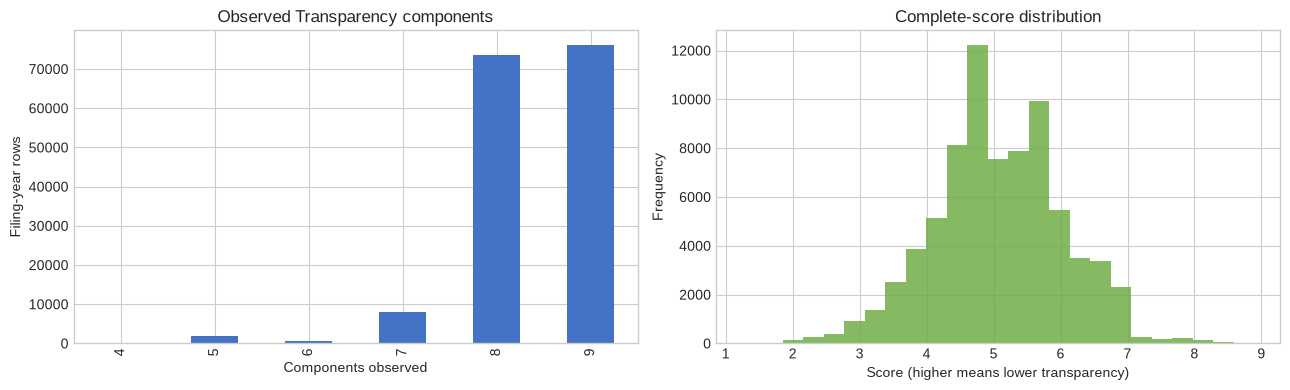

,component,missing_rows,missing_pct
0,board_members,75728,47.231110
2,website_words,15939,9.941061
7,unrestricted_net_assets,2668,1.664016
6,total_salaries,2668,1.664016
5,political_expenses,2668,1.664016
8,fundraising_expenses,56,0.034927
4,related_to_c3s,0,0.000000
1,volunteers,0,0.000000
3,related_to_527s,0,0.000000


,component,score_1_meaning,score_1_rows,score_1_pct_known,score_0_meaning,score_0_rows,score_0_pct_known,missing_rows
0,related_to_527s,related 527 identified,3387,2.112452,no related 527 identified,156948,97.887548,0
1,related_to_c3s,no related 501(c)(3) identified,151573,94.535192,related 501(c)(3) identified,8762,5.464808,0


Relationship components are fully observed because the scoring query treats no qualifying Schedule R record as an observed zero; this is different from missing source data.


,count,mean,std,min,10%,25%,50%,75%,90%,max
index_score,76034.0,5.073592,0.97027,1.23669,3.84,4.491118,5.005662,5.721536,6.358194,8.894969
normalized_index_score,76034.0,5.073592,0.97027,1.23669,3.84,4.491118,5.005662,5.721536,6.358194,8.894969


,tax_year,rows,median,mean,q25,q75
0,2016,27,4.973802,5.039150,4.596228,5.552704
1,2017,1832,4.930732,4.907753,4.283679,5.626813
2,2018,8564,5.000000,5.056975,4.469757,5.720000
3,2019,9116,4.983347,5.037029,4.474282,5.694857
4,2020,10932,4.982938,5.046857,4.454921,5.719475
5,2021,7131,4.983720,5.027183,4.471155,5.680000
6,2022,12004,5.075950,5.110092,4.521438,5.749776
7,2023,12187,5.026993,5.077841,4.505183,5.723859
8,2024,12032,5.086616,5.137732,4.525789,5.783738
9,2025,2209,5.053514,5.137830,4.570750,5.780840


,form_type,rows,median,mean
0,990,76034,5.005662,5.073592


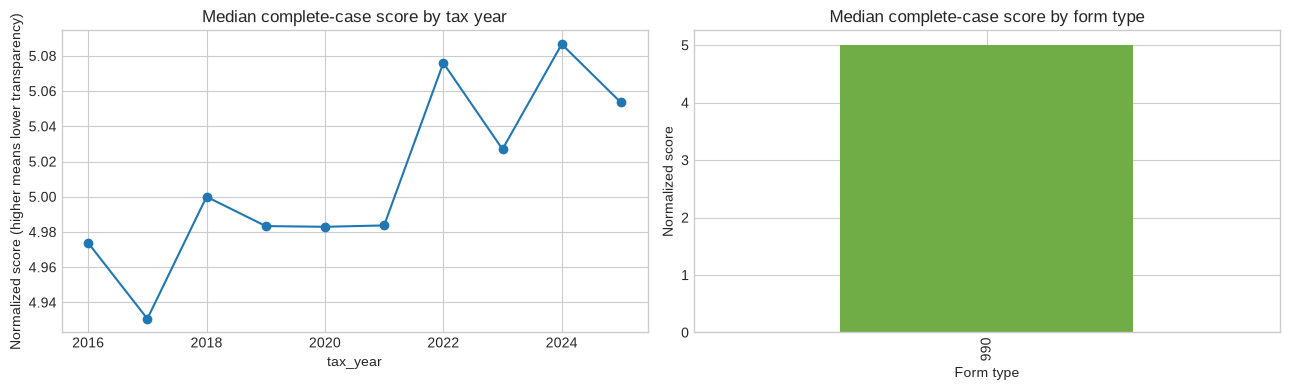

,count,mean,std,min,25%,50%,75%,max
normalized_index_score,76034.0,5.073592,0.970270,1.236690,4.491118,5.005662,5.721536,8.894969
score_without_political,76034.0,5.689911,1.075628,1.391276,5.042626,5.625000,6.435000,8.982544


,normalized_index_score,score_without_political
normalized_index_score,1.00000,0.99751
score_without_political,0.99751,1.00000


In [3]:
run_ids = all_features["run_id"].dropna().unique()
assert len(run_ids) == 1, f"Expected one score run, found {len(run_ids)}"
run_id = run_ids[0]
index_version = all_features["index_version"].iloc[0]
assert index_version == INDEX_VERSION == "irvin-9-v1"
print(f"Score run: {run_id} ({index_version})")

with sqlite3.connect(DB_PATH) as connection:
    source_rows = connection.execute(
        "SELECT COUNT(*) FROM transparency_index_source WHERE run_id = ? AND index_version = ?",
        (run_id, index_version),
    ).fetchone()[0]
assert source_rows == len(all_features)
print(f"SQL source snapshot: {source_rows:,} rows")

coverage = transparency_coverage_summary(all_features)
threshold_coverage = coverage.loc[coverage["threshold"].isin([7, 8, 9])].copy()
threshold_coverage["share"] = threshold_coverage["share"].mul(100).round(2)
display(threshold_coverage.rename(columns={"share": "coverage_pct"}))

component_coverage = coverage.loc[~coverage["threshold"].isin([7, 8, 9])].copy()
component_coverage = component_coverage.rename(
    columns={"threshold": "component", "rows": "observed_rows", "share": "coverage_pct"}
)
component_coverage["coverage_pct"] = component_coverage["coverage_pct"].mul(100).round(2)
display(component_coverage)

with sqlite3.connect(DB_PATH) as connection:
    relationship_prevalence = pd.read_sql_query(
        """
        WITH scored AS (
            SELECT s.filing_id,
                   EXISTS (
                       SELECT 1 FROM irs990_filing_related_orgs r
                       WHERE r.filing_id = s.filing_id
                         AND r.entity_type LIKE '%527%'
                   ) AS has_527,
                   EXISTS (
                       SELECT 1 FROM irs990_filing_related_orgs r
                       WHERE r.filing_id = s.filing_id
                         AND r.ein IS NOT NULL
                         AND r.entity_type LIKE '%501%(3)%'
                   ) AS has_c3
            FROM transparency_index_scores s
            WHERE s.run_id = ?
        )
        SELECT 'related_to_527s' AS component,
               COUNT(*) AS scored_rows,
               SUM(has_527) AS identified_rows,
               AVG(has_527) * 100.0 AS identified_pct
        FROM scored
        UNION ALL
        SELECT 'related_to_c3s', COUNT(*), SUM(has_c3), AVG(has_c3) * 100.0
        FROM scored
        """,
        connection,
        params=(run_id,),
    )
relationship_prevalence["identified_pct"] = relationship_prevalence["identified_pct"].round(2)
display(relationship_prevalence)
print("Relationship scores are derived binary values; 100% score coverage is not relationship prevalence.")

target_coverage = pd.DataFrame(
    {
        "rows": [
            len(exploratory),
            int(exploratory["political_activity_target"].notna().sum()),
            int(exploratory["political_activity_target"].isna().sum()),
        ]
    },
    index=["all >=8 rows", "observed target", "unknown target"],
)
display(target_coverage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
all_features["observed_components"].value_counts().sort_index().plot.bar(
    ax=axes[0], color="#4472c4"
)
axes[0].set_title("Observed Transparency components")
axes[0].set_xlabel("Components observed")
axes[0].set_ylabel("Filing-year rows")
complete["normalized_index_score"].plot.hist(
    bins=25, ax=axes[1], color="#70ad47", alpha=0.85
)
axes[1].set_title("Complete-score distribution")
axes[1].set_xlabel("Score (higher means lower transparency)")
plt.tight_layout()
plt.show()

missing_rates = pd.DataFrame({
    "component": list(TRANSPARENCY_COMPONENTS),
    "missing_rows": [
        int(all_features[f"{component}_missing"].sum())
        for component in TRANSPARENCY_COMPONENTS
    ],
})
missing_rates["missing_pct"] = (
    missing_rates["missing_rows"] / len(all_features) * 100
)
display(missing_rates.sort_values("missing_pct", ascending=False))

relationship_score_distribution = []
relationship_semantics = {
    "related_to_527s": (
        "related 527 identified",
        "no related 527 identified",
    ),
    "related_to_c3s": (
        "no related 501(c)(3) identified",
        "related 501(c)(3) identified",
    ),
}
for component, (score_1_meaning, score_0_meaning) in relationship_semantics.items():
    values = all_features[component]
    known = values.notna()
    known_count = int(known.sum())
    score_1_rows = int(values.eq(1).sum())
    score_0_rows = int(values.eq(0).sum())
    relationship_score_distribution.append({
        "component": component,
        "score_1_meaning": score_1_meaning,
        "score_1_rows": score_1_rows,
        "score_1_pct_known": score_1_rows / known_count * 100,
        "score_0_meaning": score_0_meaning,
        "score_0_rows": score_0_rows,
        "score_0_pct_known": score_0_rows / known_count * 100,
        "missing_rows": int((~known).sum()),
    })
display(pd.DataFrame(relationship_score_distribution))
print(
    "Relationship components are fully observed because the scoring query "
    "treats no qualifying Schedule R record as an observed zero; this is "
    "different from missing source data."
)

score_summary = complete[
    ["index_score", "normalized_index_score"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
display(score_summary)

score_by_year = (
    complete.groupby("tax_year")["normalized_index_score"]
    .agg(
        rows="size",
        median="median",
        mean="mean",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
display(score_by_year)

score_by_form = (
    complete.groupby("form_type")["normalized_index_score"]
    .agg(rows="size", median="median", mean="mean")
    .reset_index()
)
display(score_by_form)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
score_by_year.plot(
    x="tax_year", y="median", marker="o", ax=axes[0], legend=False
)
axes[0].set_title("Median complete-case score by tax year")
axes[0].set_ylabel("Normalized score (higher means lower transparency)")
score_by_form.plot.bar(
    x="form_type", y="median", ax=axes[1], legend=False, color="#70ad47"
)
axes[1].set_title("Median complete-case score by form type")
axes[1].set_xlabel("Form type")
axes[1].set_ylabel("Normalized score")
plt.tight_layout()
plt.show()

non_political = [
    component
    for component in TRANSPARENCY_COMPONENTS
    if component != "political_expenses"
]
score_sensitivity = complete[["normalized_index_score", *non_political]].copy()
score_sensitivity["score_without_political"] = (
    score_sensitivity[non_political].sum(axis=1)
    / len(non_political)
    * len(TRANSPARENCY_COMPONENTS)
)
score_columns = ["normalized_index_score", "score_without_political"]
display(score_sensitivity[score_columns].describe().T)
display(score_sensitivity[score_columns].corr(method="spearman"))

## 3. Disclosed political-activity classifier

This model predicts disclosed political or lobbying expenditure. Rows without an observable target are left out. I use grouped validation to keep an EIN out of both splits, and a temporal split to see how the model carries into 2024 and later. The target is disclosure, not hidden activity.

,population,rows,target_observed,positive_rate
0,all >=8 rows,149672,23777,0.286664
1,complete rows,76034,21502,0.282857


,rows,positive_rate
tax_year,,
2016,8,0.375
2017,557,0.253142
2018,2632,0.259119
2019,2739,0.266521
2020,3402,0.286302
2021,2163,0.242718
2022,3845,0.29909
2023,3842,0.306091
2024,3928,0.339104


,roc_auc,average_precision,brier_score,precision_at_0.5,recall_at_0.5,test_prevalence,average_precision_lift,train_rows,test_rows
validation,,,,,,,,,
grouped,0.908551,0.760014,0.116512,0.681055,0.824144,0.285785,2.659386,17748,6029
2024+ temporal,0.890083,0.723980,0.132450,0.677810,0.819512,0.312704,2.315223,6939,4589


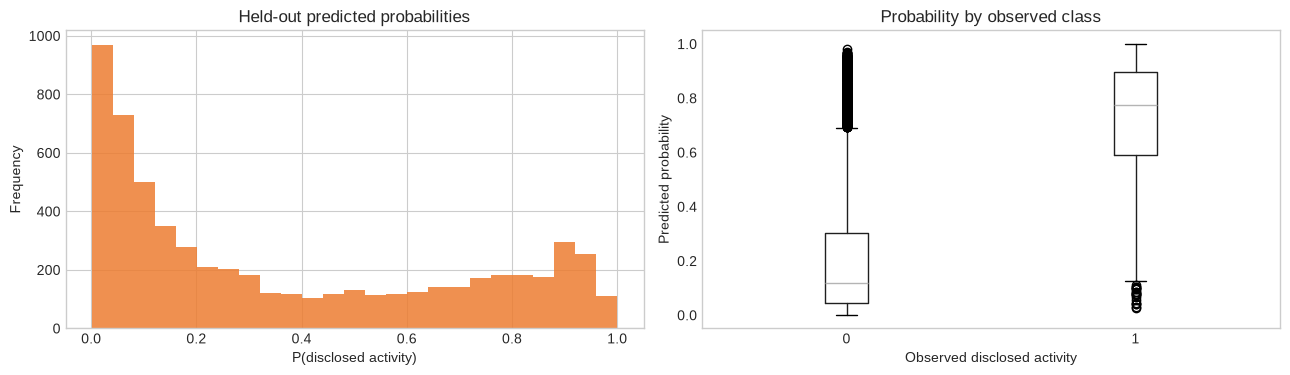

In [4]:
target_observed = exploratory["political_activity_target"].notna()
target_summary = pd.DataFrame(
    [
        {
        "population": "all >=8 rows",
        "rows": len(exploratory),
        "target_observed": int(target_observed.sum()),
        "positive_rate": exploratory.loc[
            target_observed, "political_activity_target"
        ].mean(),
        },
        {
        "population": "complete rows",
        "rows": len(complete),
        "target_observed": int(
            complete["political_activity_target"].notna().sum()
        ),
        "positive_rate": complete["political_activity_target"].mean(),
        },
    ]
)
display(target_summary)
prevalence_by_year = (
    exploratory.loc[target_observed]
    .groupby("tax_year")["political_activity_target"]
    .agg(rows="size", positive_rate="mean")
)
display(prevalence_by_year)
grouped_result = fit_political_activity_classifier(
    exploratory, split_strategy="grouped"
)
temporal_result = fit_political_activity_classifier(
    exploratory, split_strategy="temporal", test_year=2024
)
classifier_result = grouped_result
model_metrics = pd.DataFrame(
    [
        {
            "validation": "grouped",
            **grouped_result.metrics,
            "train_rows": grouped_result.train_rows,
            "test_rows": grouped_result.test_rows,
        },
        {
            "validation": "2024+ temporal",
            **temporal_result.metrics,
            "train_rows": temporal_result.train_rows,
            "test_rows": temporal_result.test_rows,
        },
    ]
).set_index("validation")
display(model_metrics)
assert grouped_result.train_rows > 0
assert temporal_result.test_rows > 0
assert 0 <= grouped_result.metrics["roc_auc"] <= 1
assert 0 <= temporal_result.metrics["roc_auc"] <= 1

predictions = grouped_result.predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
predictions["predicted_probability"].plot.hist(
    bins=25, ax=axes[0], color="#ed7d31", alpha=0.85
)
axes[0].set_title("Held-out predicted probabilities")
axes[0].set_xlabel("P(disclosed activity)")
predictions.boxplot(
    column="predicted_probability", by="observed", ax=axes[1], grid=False
)
axes[1].set_title("Probability by observed class")
axes[1].set_xlabel("Observed disclosed activity")
axes[1].set_ylabel("Predicted probability")
fig.suptitle("")
plt.tight_layout()
plt.show()




## 4. Organization network analysis

The graph combines grant and related-organization edges, while keeping the two edge types separate in the summaries. Placeholder EINs are excluded. I use this as a way to find records worth reading, not as a causal measure of influence.

,value
nodes,358.00000
edges,278.00000
communities,147.00000
density,0.00435
connected_components,147.00000
largest_component,66.00000
grant_edges,146.00000
related_edges,132.00000
excluded_placeholder_edges,19.00000


,ein,degree,grant_degree,grant_amount,grant_log_strength,related_degree,related_supporting_rows,betweenness,pagerank,community
0,561776668,1,1,1.406805e+10,23.367172,0,0,0.000000,0.002793,12
1,560532129,1,1,1.406805e+10,23.367172,0,0,0.000000,0.002793,12
35,110303001,9,9,1.105896e+10,23.126506,0,0,0.001359,0.009176,2
5,416011702,3,3,1.039609e+10,23.064696,0,0,0.000047,0.005362,6
2,351044585,1,1,9.598521e+09,22.984875,0,0,0.000000,0.002793,13
3,620646012,1,1,9.598521e+09,22.984875,0,0,0.000000,0.002793,13
29,311640316,8,8,8.909712e+09,22.910408,0,0,0.001398,0.007705,2
4,383952644,1,1,8.722142e+09,22.889131,0,0,0.000000,0.001937,6
36,237825575,6,6,8.674964e+09,22.883707,0,0,0.000674,0.005694,2
9,596002052,4,4,8.486343e+09,22.861724,0,0,0.000094,0.006646,4


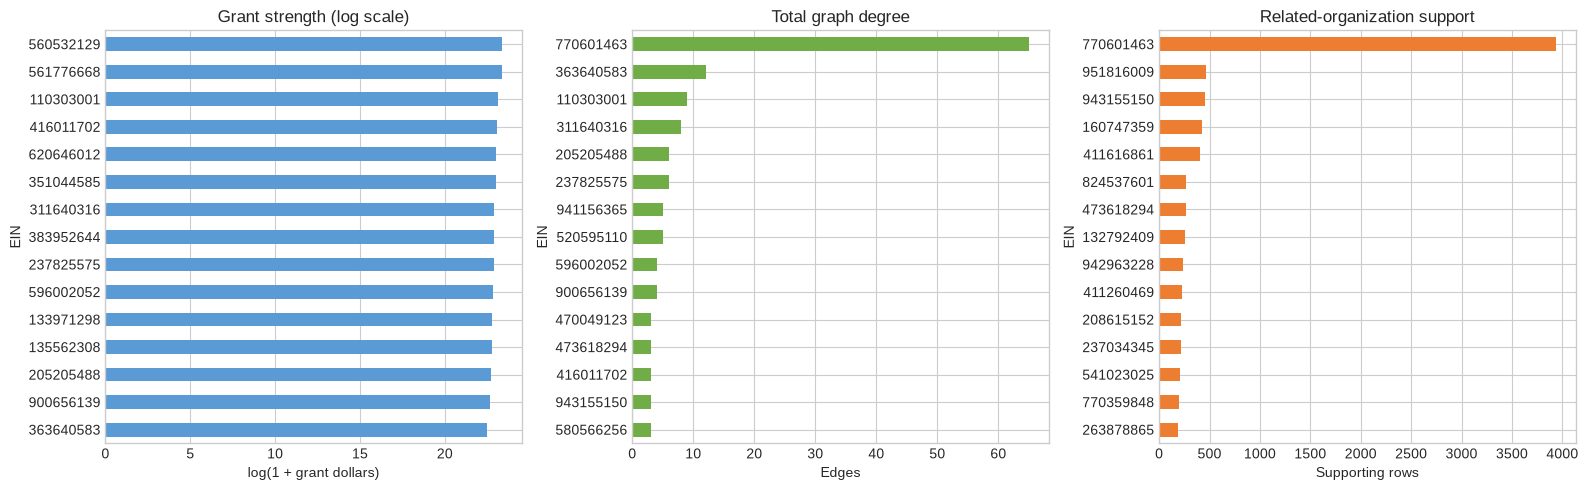

In [5]:
network_result = analyze_organization_network(DB_PATH, max_edges_per_type=150)
display(pd.Series(network_result.summary, name="value").to_frame())
grant_nodes = network_result.node_features.nlargest(15, "grant_amount")
degree_nodes = network_result.node_features.nlargest(15, "degree")
related_nodes = network_result.node_features.nlargest(15, "related_supporting_rows")
display(grant_nodes)
assert network_result.summary["nodes"] > 0
assert network_result.summary["edges"] > 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
grant_nodes.sort_values("grant_log_strength").plot.barh(
    x="ein", y="grant_log_strength", ax=axes[0], legend=False, color="#5b9bd5"
)
axes[0].set_title("Grant strength (log scale)")
axes[0].set_xlabel("log(1 + grant dollars)")
degree_nodes.sort_values("degree").plot.barh(
    x="ein", y="degree", ax=axes[1], legend=False, color="#70ad47"
)
axes[1].set_title("Total graph degree")
axes[1].set_xlabel("Edges")
related_nodes.sort_values("related_supporting_rows").plot.barh(
    x="ein", y="related_supporting_rows", ax=axes[2], legend=False, color="#ed7d31"
)
axes[2].set_title("Related-organization support")
axes[2].set_xlabel("Supporting rows")
for axis in axes:
    axis.set_ylabel("EIN")
plt.tight_layout()
plt.show()




## 5. Unsupervised structure and anomaly review

These two methods are used to make a review list. Their labels are not findings about an organization. The tables below show the highest-ranked rows, the overlap between methods, and the component differences behind the flags.

{'rows': 76034, 'clusters': 64, 'cluster_noise': 622, 'anomalies': 3802}


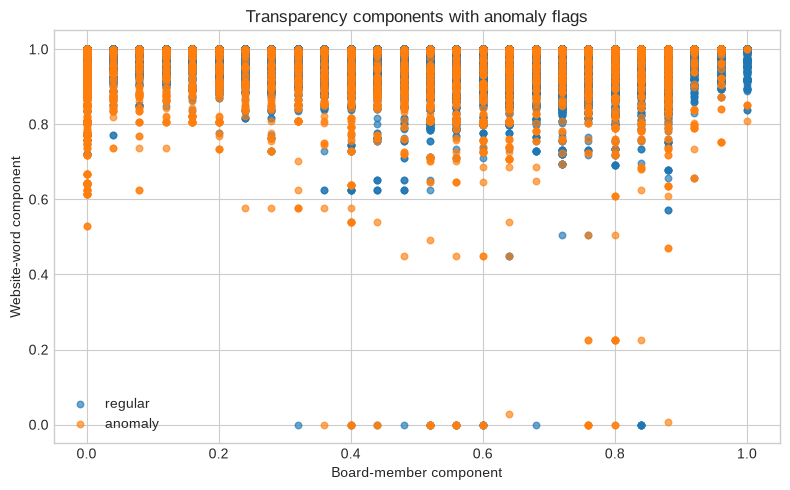

Isolation Forest flagged 3,802 of 76,034 complete rows (5.0%); higher anomaly scores mean greater isolation, not greater misconduct or severity.


,outlier_rank,filing_id,ein,tax_year,filer_name,normalized_index_score,anomaly_score,cluster_label,board_members,volunteers,website_words,related_to_527s,related_to_c3s,political_expenses,total_salaries,unrestricted_net_assets,fundraising_expenses
3727,1,833514,133976062,2020,NRDC ACTION FUND INC,5.776374,0.135924,13,0.00,1.0,0.75852,1.0,0.0,0.625949,0.762157,0.650002,0.979747
3729,2,2976610,133976062,2022,NRDC ACTION FUND INC,5.769347,0.131932,13,0.00,1.0,0.75852,1.0,0.0,0.541061,0.808062,0.679338,0.982366
3731,3,4456054,133976062,2024,NRDC ACTION FUND INC,5.856204,0.130937,13,0.00,1.0,0.75852,1.0,0.0,0.551564,0.800025,0.823747,0.922347
3730,4,3684692,133976062,2023,NRDC ACTION FUND INC,5.541238,0.130441,13,0.00,1.0,0.75852,1.0,0.0,0.453181,0.751098,0.599489,0.978950
3728,5,2221008,133976062,2021,NRDC ACTION FUND INC,5.890629,0.128354,13,0.00,1.0,0.75852,1.0,0.0,0.545518,0.846304,0.762412,0.977876
45002,6,4050283,550828701,2024,PROVIDENCE HEALTH ASSURANCE,1.640030,0.125882,-1,0.00,1.0,0.64003,0.0,0.0,0.000000,0.000000,0.000000,0.000000
45001,7,3299661,550828701,2023,PROVIDENCE HEALTH ASSURANCE,1.640030,0.125882,-1,0.00,1.0,0.64003,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3726,8,1742919,133976062,2018,NRDC Action Fund Inc,5.932100,0.119005,-1,0.00,1.0,0.75852,1.0,0.0,0.415113,0.758467,1.000000,1.000000
61585,9,1619217,824578595,2019,BLACK ECONOMIC ALLIANCE,5.436142,0.118618,-1,0.64,1.0,0.02773,1.0,0.0,0.081242,0.769391,0.973307,0.944473
26235,10,3545336,371866867,2023,CHILDREN FIRST ACTION FUND,5.360000,0.117215,-1,0.36,1.0,0.00000,0.0,1.0,1.000000,1.000000,0.000000,1.000000


,measure,rows,share_of_complete
0,Isolation Forest flagged,3802,0.050004
1,DBSCAN noise,622,0.008181
2,Both methods,491,0.006458


,measure,value
0,Overlap rows,491
1,Share of Isolation Forest flags,12.9%
2,Share of DBSCAN noise,78.9%
3,Share of complete rows,0.6%


,overlap_rank,filing_id,ein,tax_year,filer_name,normalized_index_score,anomaly_score,cluster_label,board_members,volunteers,website_words,related_to_527s,related_to_c3s,political_expenses,total_salaries,unrestricted_net_assets,fundraising_expenses
45002,1,4050283,550828701,2024,PROVIDENCE HEALTH ASSURANCE,1.640030,0.125882,-1,0.00,1.0,0.64003,0.0,0.0,0.000000,0.000000,0.000000,0.000000
45001,2,3299661,550828701,2023,PROVIDENCE HEALTH ASSURANCE,1.640030,0.125882,-1,0.00,1.0,0.64003,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3726,3,1742919,133976062,2018,NRDC Action Fund Inc,5.932100,0.119005,-1,0.00,1.0,0.75852,1.0,0.0,0.415113,0.758467,1.000000,1.000000
61585,4,1619217,824578595,2019,BLACK ECONOMIC ALLIANCE,5.436142,0.118618,-1,0.64,1.0,0.02773,1.0,0.0,0.081242,0.769391,0.973307,0.944473
26235,5,3545336,371866867,2023,CHILDREN FIRST ACTION FUND,5.360000,0.117215,-1,0.36,1.0,0.00000,0.0,1.0,1.000000,1.000000,0.000000,1.000000
70317,6,3122507,920272851,2023,FLORIDIANS FOR HOUSING OPPORTUNITY PC,7.811246,0.113758,-1,0.96,1.0,0.90552,1.0,1.0,0.945726,1.000000,1.000000,0.000000
61586,7,54974,824578595,2020,BLACK ECONOMIC ALLIANCE,5.371117,0.113689,-1,0.56,1.0,0.00000,1.0,0.0,0.239728,0.788853,0.787876,0.994660
60479,8,701141,821246245,2020,AMERICAN COALITION FOR PUBLIC RADIO,4.560488,0.112219,-1,0.00,0.0,0.71925,0.0,0.0,0.841238,1.000000,1.000000,1.000000
3440,9,1669219,132630359,2018,NARAL PRO-CHOICE AMERICA,4.960556,0.109718,-1,0.40,0.0,0.98913,1.0,0.0,0.492420,0.162818,0.939241,0.976948
26236,10,4150027,371866867,2024,CHILDREN FIRST ACTION FUND,6.156130,0.108788,-1,0.40,1.0,0.00000,0.0,1.0,1.000000,1.000000,0.756130,1.000000


,complete_median,overlap_median,median_difference
volunteers,1.00000,0.000000,-1.000000
related_to_c3s,1.00000,0.000000,-1.000000
political_expenses,0.00000,0.304868,0.304868
unrestricted_net_assets,0.56569,0.735513,0.169823
total_salaries,1.00000,0.830598,-0.169402
website_words,1.00000,0.904480,-0.095520
board_members,0.68000,0.600000,-0.080000
related_to_527s,0.00000,0.000000,0.000000
fundraising_expenses,1.00000,1.000000,0.000000


,tax_year,rows
0,2017,11
1,2018,41
2,2019,47
3,2020,71
4,2021,35
5,2022,78
6,2023,87
7,2024,114
8,2025,7


,all_complete_median,outlier_median,all_complete_mean,outlier_mean
board_members,0.68000,0.480000,0.612142,0.455960
volunteers,1.00000,0.000000,0.504103,0.383482
website_words,1.00000,0.937170,0.981549,0.911002
related_to_527s,0.00000,0.000000,0.038733,0.490794
related_to_c3s,1.00000,0.000000,0.894061,0.289058
political_expenses,0.00000,0.002775,0.015893,0.141162
total_salaries,1.00000,0.777102,0.848839,0.711733
unrestricted_net_assets,0.56569,0.816942,0.485390,0.653703
fundraising_expenses,1.00000,0.995229,0.692882,0.610220


In [6]:
matrix = complete[list(TRANSPARENCY_COMPONENTS)].dropna()
cluster_result = dbscan_clusters(
    matrix, eps=1.2, min_samples=5, scale=True
)
anomaly_result = isolation_forest_anomalies(
    matrix, contamination=0.05, n_estimators=100, random_state=42
)
print(
    {
        "rows": len(matrix),
        "clusters": cluster_result.n_clusters,
        "cluster_noise": cluster_result.noise_count,
        "anomalies": anomaly_result.anomaly_count,
    }
)
assert len(cluster_result.labels) == len(matrix)
assert len(anomaly_result.anomaly_scores) == len(matrix)
assert 0 <= anomaly_result.anomaly_count <= len(matrix)

plot_data = complete.loc[
    matrix.index, ["board_members", "website_words"]
].copy()
plot_data["anomaly"] = anomaly_result.labels == -1
fig, ax = plt.subplots(figsize=(8, 5))
for label, group in plot_data.groupby("anomaly"):
    ax.scatter(
        group["board_members"], group["website_words"],
        s=22, alpha=0.65, label="anomaly" if label else "regular"
)
ax.set_title("Transparency components with anomaly flags")
ax.set_xlabel("Board-member component")
ax.set_ylabel("Website-word component")
ax.legend()
plt.tight_layout()
plt.show()

outlier_frame = complete.loc[matrix.index].copy()
outlier_frame["cluster_label"] = cluster_result.labels
outlier_frame["anomaly_score"] = anomaly_result.anomaly_scores
outlier_frame["anomaly_flag"] = anomaly_result.labels == -1
outlier_frame = outlier_frame.sort_values("anomaly_score", ascending=False)
outlier_rows = outlier_frame.loc[outlier_frame["anomaly_flag"]].copy()
outlier_rows["outlier_rank"] = range(1, len(outlier_rows) + 1)
outlier_columns = [
    "outlier_rank", "filing_id", "ein", "tax_year", "filer_name",
    "normalized_index_score", "anomaly_score", "cluster_label",
] + list(TRANSPARENCY_COMPONENTS)
print(
    f"Isolation Forest flagged {len(outlier_rows):,} of {len(matrix):,} "
    f"complete rows ({len(outlier_rows) / len(matrix):.1%}); higher anomaly scores "
    "mean greater isolation, not greater misconduct or severity."
)
display(outlier_rows[outlier_columns].head(20))

outlier_overlap = pd.DataFrame({
    "measure": [
        "Isolation Forest flagged",
        "DBSCAN noise",
        "Both methods",
    ],
    "rows": [
        int(outlier_frame["anomaly_flag"].sum()),
        int((outlier_frame["cluster_label"] == -1).sum()),
        int((outlier_frame["anomaly_flag"] & outlier_frame["cluster_label"].eq(-1)).sum()),
    ],
})
outlier_overlap["share_of_complete"] = outlier_overlap["rows"] / len(matrix)
display(outlier_overlap)

overlap_rows = outlier_frame.loc[
    outlier_frame["anomaly_flag"] & outlier_frame["cluster_label"].eq(-1)
].copy()
overlap_rows["overlap_rank"] = range(1, len(overlap_rows) + 1)
overlap_summary = pd.DataFrame({
    "measure": [
        "Overlap rows",
        "Share of Isolation Forest flags",
        "Share of DBSCAN noise",
        "Share of complete rows",
    ],
    "value": [
        str(len(overlap_rows)),
        f"{len(overlap_rows) / len(outlier_rows):.1%}",
        f"{len(overlap_rows) / int((outlier_frame['cluster_label'] == -1).sum()):.1%}",
        f"{len(overlap_rows) / len(matrix):.1%}",
    ],
})
display(overlap_summary)
overlap_columns = [
    "overlap_rank", "filing_id", "ein", "tax_year", "filer_name",
    "normalized_index_score", "anomaly_score", "cluster_label",
] + list(TRANSPARENCY_COMPONENTS)
display(overlap_rows[overlap_columns].head(15))

overlap_component_summary = pd.DataFrame({
    "complete_median": matrix.median(),
    "overlap_median": overlap_rows[list(TRANSPARENCY_COMPONENTS)].median(),
})
overlap_component_summary["median_difference"] = (
    overlap_component_summary["overlap_median"]
    - overlap_component_summary["complete_median"]
)
overlap_component_summary["absolute_difference"] = (
    overlap_component_summary["median_difference"].abs()
)
display(
    overlap_component_summary.sort_values(
        "absolute_difference", ascending=False
    ).drop(columns="absolute_difference")
)
overlap_years = (
    overlap_rows["tax_year"]
    .value_counts()
    .sort_index()
    .rename_axis("tax_year")
    .reset_index(name="rows")
)
display(overlap_years)

outlier_component_summary = pd.DataFrame({
    "all_complete_median": matrix.median(),
    "outlier_median": outlier_rows[list(TRANSPARENCY_COMPONENTS)].median(),
    "all_complete_mean": matrix.mean(),
    "outlier_mean": outlier_rows[list(TRANSPARENCY_COMPONENTS)].mean(),
})
display(outlier_component_summary)

## 6. Analysis scope

The notebook covers the index, disclosed political-activity prediction, organization relationships, and unsupervised review candidates. It does not attempt lobbying-text, bill-text, or bill-outcome modeling.

In [7]:
scope = pd.DataFrame(
    [
        {"analysis": "Transparency Index coverage", "rows": len(all_features)},
        {"analysis": "Disclosed political-activity classifier", "rows": classifier_result.test_rows},
        {"analysis": "Organization network", "rows": network_result.summary["edges"]},
        {"analysis": "Clustering and anomaly review", "rows": len(matrix)},
    ]
)
display(scope)

,analysis,rows
0,Transparency Index coverage,160335
1,Disclosed political-activity classifier,6029
2,Organization network,278
3,Clustering and anomaly review,76034


## What the current data says

These results use score run **20260810T223920719342Z** and index version **irvin-9-v1**. Scores and the source snapshot are loaded from SQLite; Parquet is an optional export. The main limitation remains measurement: many filing-year rows are scored, but the underlying evidence is uneven.

### Coverage comes first

The score run contains **160,335 filing-year rows**. **76,034 (47.42%)** have all nine components observed, **149,672 (93.35%)** have at least eight, and **157,667 (98.34%)** have at least seven. The expanded complete population is primarily a consequence of the explicit zero-default policy for selected missing fields; it should not be read as equivalent to newly observed data. Board-member data remains the main coverage constraint (**52.77%** observed). Website scores are non-missing for **90.06%** of rows because filings without a usable website receive an explicit zero-word score, but only **33.1%** have a successful or partial website observation linked to the score. Fundraising expenses are observed for **99.97%** of rows. Missingness is a limit on what can be observed; it is not itself a low-transparency score.

### What the index looks like

For the complete rows, the median normalized score is **5.01**, with an interquartile range of **4.49–5.72**. Complete cases now span tax years **2016–2025**, so year comparisons are descriptive and should not be interpreted as a causal trend; current website crawls and the infill rules affect comparability. The relationship fields are fully populated because no qualifying record is coded as zero, not because every relationship was observed. The direct Schedule R check identifies a related 527 in **1.21%** of rows and a related 501(c)(3) in **5.46%**; the broader 527 score query, which also includes 527-organization records, marks **2.11%**. The C3 component is coded in the opposite direction: score 1 means no related C3 was identified, and score 0 means one was identified.

Removing political expenses changes the score level, but not the ordering very much. The Spearman correlation between the two complete-case rankings is **0.998**. That is a useful robustness check, not proof that the index measures transparency perfectly.

### The downstream models are narrower

Among the **149,672** rows with at least eight components, only **23,777** have an observable disclosed-activity target; **125,895** are unknown and excluded from classifier evaluation. The grouped classifier reaches a ROC-AUC of **0.909** and **2.66x** average-precision lift. The 2024+ temporal validation reaches a ROC-AUC of **0.890** and **2.32x** lift. This suggests that the available financial and mission fields contain information about **disclosed** political activity. It does not tell us about activity that was not reported.

The organization graph has **358 nodes** and **278 edges**, and its largest connected component covers **18.4%** of nodes. The relationships are fragmented rather than one dense network. That makes the graph useful for finding records to inspect, but not for making causal claims about influence.

The anomaly methods also produce a larger, more clearly defined review population: Isolation Forest flags **3,802 (5.0%)** complete rows and DBSCAN marks **622 (0.8%)** as noise. **491 rows (0.6% of complete rows)** appear in both groups; this is **12.9%** of Isolation Forest flags and **78.9%** of DBSCAN noise. In the overlap, the median volunteer and C3 components are both **0** versus **1.0** among complete rows, while the median political-expense component is **0.305** versus **0**. These are unusual combinations of reported components for review, not evidence of misconduct.
